# Análise de Dados — Performance de Estudantes

Esta etapa do profissional de análise de dados utiliza exclusivamente as tabelas analíticas geradas na camada Gold do lakehouse SQLite.

O objetivo deste notebook é responder três perguntas centrais do projeto:

- O que aconteceu com o desempenho acadêmico dos estudantes?
- Quais fatores parecem mais associados ao GPA e ao risco de reprovação?
- Quais perfis merecem mais atenção da gestão escolar e dos professores?

Base original: dataset público de desempenho estudantil extraído do Kaggle.

Fonte analítica utilizada neste notebook: `dim_aluno`, `fato_desempenho` e tabelas `gold_*` geradas após a etapa de engenharia de dados.

## Roteiro Analítico

1. Carregar a base analítica no SQLite e validar a estrutura disponível.
2. Fazer uma leitura descritiva do desempenho geral dos alunos.
3. Investigar fatores associados ao GPA, como estudo, faltas, tutoria e suporte parental.
4. Combinar variáveis para identificar perfis de maior risco acadêmico.
5. Registrar conclusões acionáveis para apresentação e tomada de decisão.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

sns.set_theme(style="whitegrid", palette="Blues")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

In [2]:
DB_PATH = Path("../../data/data_lakehouse.db").resolve()
conn = sqlite3.connect(DB_PATH)

dim_aluno = pd.read_sql("SELECT * FROM dim_aluno", conn)
fato_desempenho = pd.read_sql("SELECT * FROM fato_desempenho", conn)

gold_distribuicao_gradeclass = pd.read_sql("SELECT * FROM gold_distribuicao_gradeclass", conn)
gold_taxa_aprovacao = pd.read_sql("SELECT * FROM gold_taxa_aprovacao", conn)
gold_gpa_por_suporte_parental = pd.read_sql("SELECT * FROM gold_gpa_por_suporte_parental", conn)
gold_gpa_por_educacao_pais = pd.read_sql("SELECT * FROM gold_gpa_por_educacao_pais", conn)
gold_gpa_por_tutoria = pd.read_sql("SELECT * FROM gold_gpa_por_tutoria", conn)
gold_gpa_por_extracurricular = pd.read_sql("SELECT * FROM gold_gpa_por_extracurricular", conn)
gold_gpa_faixas_estudo = pd.read_sql("SELECT * FROM gold_gpa_faixas_estudo", conn)
gold_gpa_faixas_faltas = pd.read_sql("SELECT * FROM gold_gpa_faixas_faltas", conn)
gold_gpa_por_idade = pd.read_sql("SELECT * FROM gold_gpa_por_idade", conn)
gold_gpa_perfil_dedicado = pd.read_sql("SELECT * FROM gold_gpa_perfil_dedicado", conn)
gold_correlacao_com_gpa = pd.read_sql("SELECT * FROM gold_correlacao_com_gpa", conn)

print(f"Banco utilizado: {DB_PATH}")
print(f"Registros em dim_aluno: {len(dim_aluno)}")
print(f"Registros em fato_desempenho: {len(fato_desempenho)}")

Banco utilizado: /home/taveira/development/drafts/students_perfomance_topicos_i/data/data_lakehouse.db
Registros em dim_aluno: 2392
Registros em fato_desempenho: 2392


In [ ]:
df_analise = dim_aluno.merge(fato_desempenho, on="StudentID", how="inner")

df_analise["situacao"] = np.where(
    df_analise["GradeClass"].isin([0, 1, 2]),
    "Aprovado",
    "Em risco / Reprovado",
)

df_analise["perfil_dedicado"] = np.where(
    (df_analise["StudyTimeWeekly"] >= 10) & (df_analise["Absences"] <= 10),
    "Dedicado",
    "Demais perfis",
)

ordem_suporte = (
    gold_gpa_por_suporte_parental
    .sort_values("ParentalSupport")["ParentalSupport_label"]
    .tolist()
)

visao_tabelas = pd.DataFrame(
    [
        {"tabela": "dim_aluno", "linhas": len(dim_aluno), "colunas": dim_aluno.shape[1]},
        {"tabela": "fato_desempenho", "linhas": len(fato_desempenho), "colunas": fato_desempenho.shape[1]},
        {"tabela": "base_analitica", "linhas": len(df_analise), "colunas": df_analise.shape[1]},
    ]
)

display(visao_tabelas)
df_analise.head()

,tabela,linhas,colunas
0,dim_aluno,2392,8
1,fato_desempenho,2392,16
2,base_analitica,2392,25


,StudentID,Age,Gender,Gender_label,ParentalEducation,ParentalEducation_label,ParentalSupport,ParentalSupport_label,StudyTimeWeekly,Absences,Tutoring,Tutoring_label,Extracurricular,Extracurricular_label,Sports,Sports_label,Music,Music_label,Volunteering,Volunteering_label,GPA,GradeClass,GradeClass_label,situacao,perfil_dedicado
0,1001,17,1,Feminino,2,Faculdade Incompleta,2,Moderado,19.83,7,1,Sim,0,Não,0,Não,1,Sim,0,Não,2.93,2,C (2.5 <= GPA < 3.0),Aprovado,Dedicado
1,1002,18,0,Masculino,1,Ensino Médio,1,Baixo,15.41,0,0,Não,0,Não,0,Não,0,Não,0,Não,3.04,1,B (3.0 <= GPA < 3.5),Aprovado,Dedicado
2,1003,15,0,Masculino,3,Bacharelado,2,Moderado,4.21,26,0,Não,0,Não,0,Não,0,Não,0,Não,0.11,4,F (GPA < 2.0),Em risco / Reprovado,Demais perfis
3,1004,17,1,Feminino,3,Bacharelado,3,Alto,10.03,14,0,Não,1,Sim,0,Não,0,Não,0,Não,2.05,3,D (2.0 <= GPA < 2.5),Em risco / Reprovado,Demais perfis
4,1005,17,1,Feminino,2,Faculdade Incompleta,3,Alto,4.67,17,1,Sim,0,Não,0,Não,0,Não,0,Não,1.29,4,F (GPA < 2.0),Em risco / Reprovado,Demais perfis


## 1. Visão Geral da Base Analítica

Antes de analisar os fatores que influenciam o desempenho, precisamos confirmar se a base consolidada está íntegra.

Este bloco responde duas perguntas operacionais:

- A junção entre dimensão e fato ficou consistente?
- Há sinais de problemas básicos de qualidade, como nulos ou distribuição muito irregular nas variáveis principais?

In [4]:
taxa_aprovacao = gold_taxa_aprovacao.loc[
    gold_taxa_aprovacao["situacao"] == "Aprovado",
    "percentual",
].iloc[0]

resumo_kpis = pd.DataFrame(
    [
        {"indicador": "Total de alunos", "valor": len(df_analise)},
        {"indicador": "GPA médio geral", "valor": df_analise["GPA"].mean()},
        {"indicador": "GPA mediano", "valor": df_analise["GPA"].median()},
        {"indicador": "Taxa de aprovação (%)", "valor": taxa_aprovacao},
        {"indicador": "Horas médias de estudo por semana", "valor": df_analise["StudyTimeWeekly"].mean()},
        {"indicador": "Faltas médias", "valor": df_analise["Absences"].mean()},
    ]
)

nulos = (
    df_analise.isna()
    .sum()
    .reset_index(name="valores_nulos")
    .rename(columns={"index": "coluna"})
    .query("valores_nulos > 0")
    .sort_values("valores_nulos", ascending=False)
)

estatisticas = df_analise[["GPA", "StudyTimeWeekly", "Absences"]].describe().T

display(resumo_kpis)
display(
    nulos
    if not nulos.empty
    else pd.DataFrame(
        {"qualidade_dos_dados": ["Nenhuma coluna com valores nulos na base analítica consolidada."]}
    )
)
display(estatisticas)

,indicador,valor
0,Total de alunos,"2,392.00"
1,GPA médio geral,1.91
2,GPA mediano,1.89
3,Taxa de aprovação (%),32.07
4,Horas médias de estudo por semana,9.77
5,Faltas médias,14.54


,qualidade_dos_dados
0,Nenhuma coluna com valores nulos na base analí...


,count,mean,std,min,25%,50%,75%,max
GPA,"2,392.00",1.91,0.92,0.00,1.17,1.89,2.62,4.00
StudyTimeWeekly,"2,392.00",9.77,5.65,0.00,5.04,9.71,14.41,19.98
Absences,"2,392.00",14.54,8.47,0.00,7.00,15.00,22.00,29.00


## 2. Análise Descritiva — O que aconteceu?

A análise descritiva resume o estado atual do desempenho acadêmico.

Aqui, o foco é entender:

- Como o GPA está distribuído na base?
- Quais classes de nota concentram mais alunos?
- O volume de alunos aprovados é maior ou menor do que o de alunos em risco?

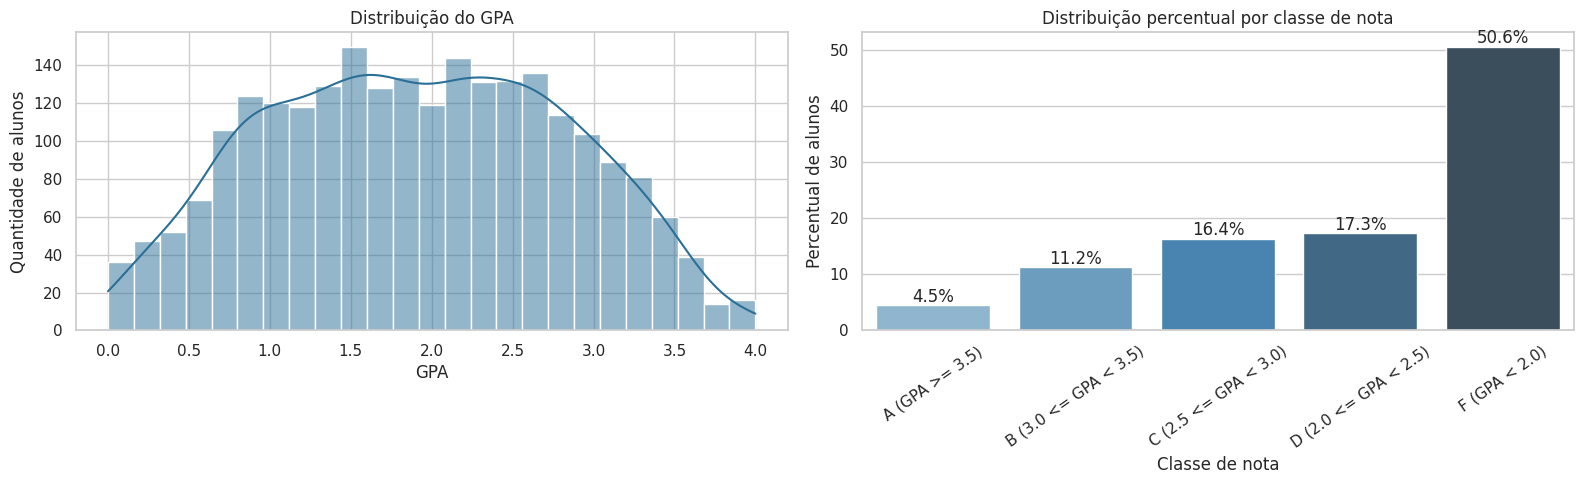

,GradeClass,GradeClass_label,quantidade,percentual
0,0,A (GPA >= 3.5),107,4.47
1,1,B (3.0 <= GPA < 3.5),269,11.25
2,2,C (2.5 <= GPA < 3.0),391,16.35
3,3,D (2.0 <= GPA < 2.5),414,17.31
4,4,F (GPA < 2.0),1211,50.63


In [5]:
dist_grade = gold_distribuicao_gradeclass.sort_values("GradeClass")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=df_analise,
    x="GPA",
    bins=25,
    kde=True,
    ax=axes[0],
    color="#2a6f97",
)
axes[0].set_title("Distribuição do GPA")
axes[0].set_xlabel("GPA")
axes[0].set_ylabel("Quantidade de alunos")

sns.barplot(
    data=dist_grade,
    x="GradeClass_label",
    y="percentual",
    hue="GradeClass_label",
    dodge=False,
    legend=False,
    palette="Blues_d",
    ax=axes[1],
)
axes[1].set_title("Distribuição percentual por classe de nota")
axes[1].set_xlabel("Classe de nota")
axes[1].set_ylabel("Percentual de alunos")
axes[1].tick_params(axis="x", rotation=35)

for index, value in enumerate(dist_grade["percentual"]):
    axes[1].text(index, value + 0.6, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

display(dist_grade)

In [6]:
fig = px.bar(
    gold_taxa_aprovacao,
    x="situacao",
    y="percentual",
    text="percentual",
    color="situacao",
    title="Taxa de aprovação versus risco acadêmico",
)
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig.update_layout(
    xaxis_title="Situação acadêmica",
    yaxis_title="Percentual de alunos",
    showlegend=False,
)
fig.show()

fig = px.box(
    df_analise,
    x="Gender_label",
    y="GPA",
    color="Gender_label",
    points="outliers",
    title="Distribuição do GPA por gênero",
)
fig.update_layout(xaxis_title="Gênero", yaxis_title="GPA")
fig.show()

## 3. Análise Diagnóstica — Por que aconteceu?

Nesta etapa, o objetivo é investigar fatores que ajudam a explicar a diferença de desempenho entre os alunos.

Os gráficos abaixo observam o GPA sob a ótica de hábitos de estudo, frequência, suporte familiar e apoio acadêmico.

A leitura correta aqui é associativa: o notebook identifica padrões fortes de comportamento, mas não prova causalidade isoladamente.

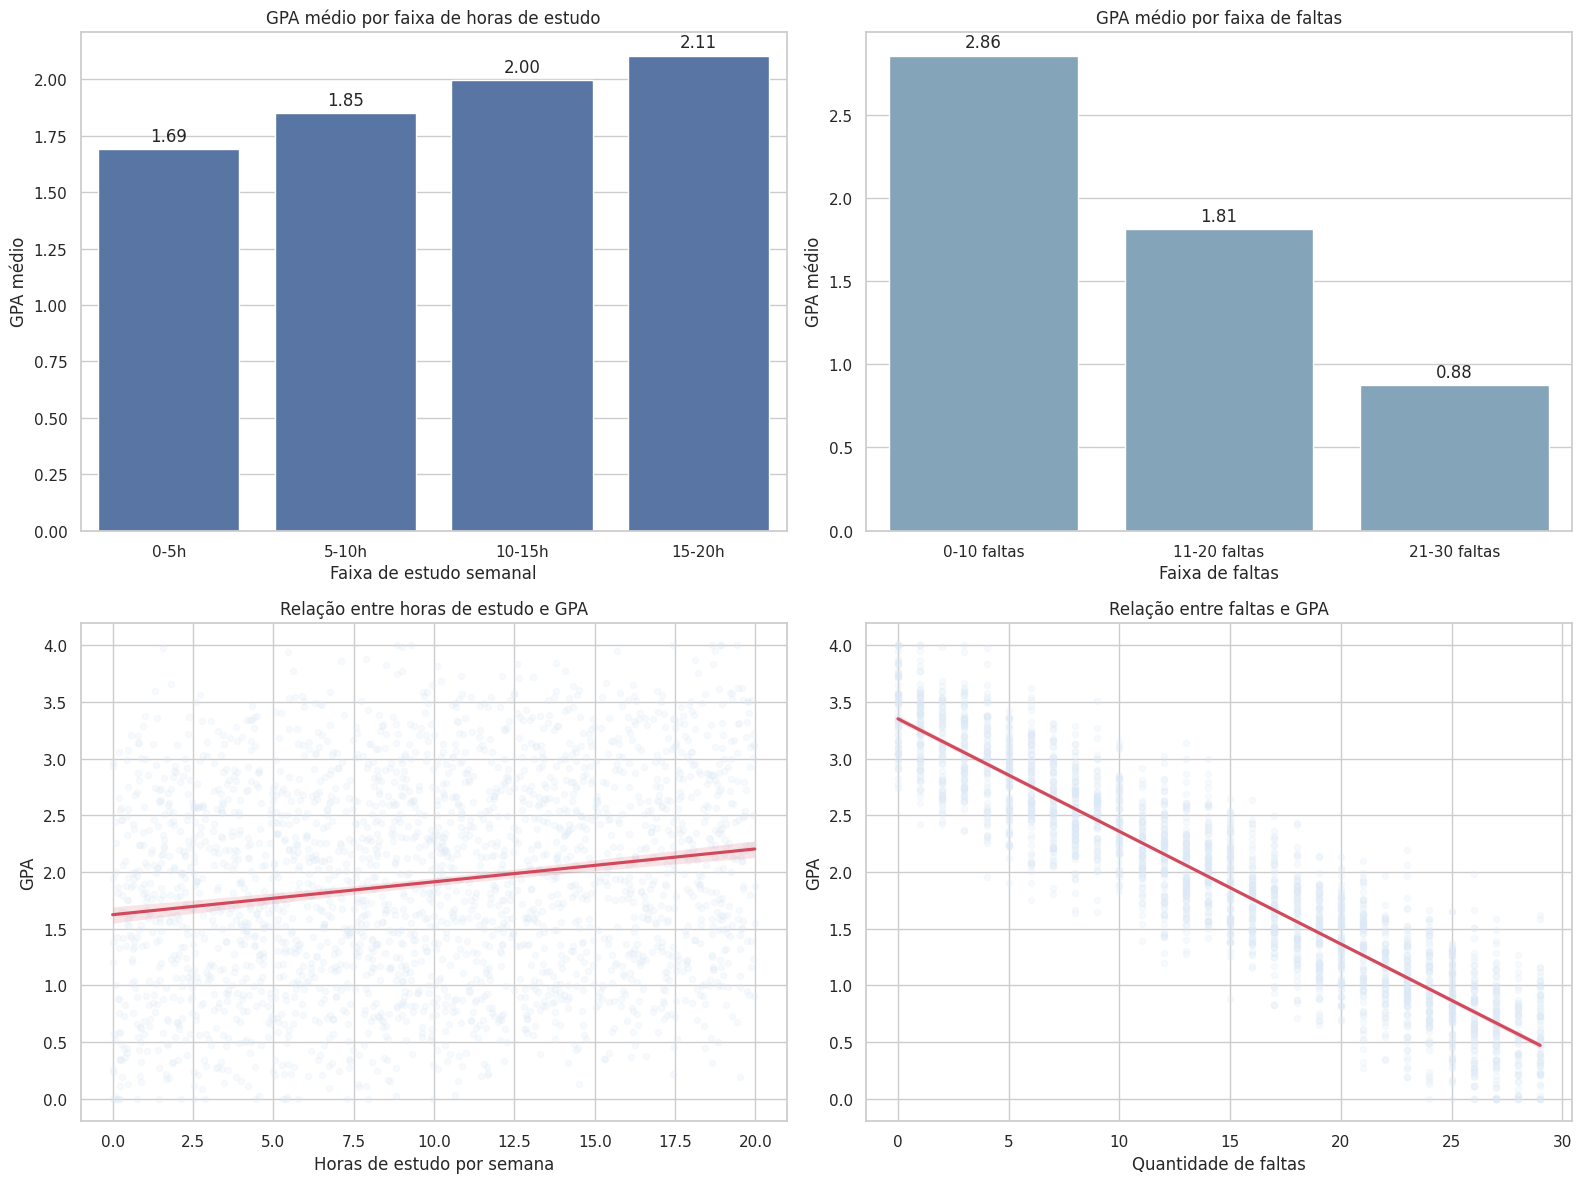

In [7]:
ordem_estudo = ["0-5h", "5-10h", "10-15h", "15-20h"]
ordem_faltas = ["0-10 faltas", "11-20 faltas", "21-30 faltas"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(
    data=gold_gpa_faixas_estudo,
    x="faixa_estudo",
    y="media_gpa",
    order=ordem_estudo,
    color="#4C72B0",
    ax=axes[0, 0],
)
axes[0, 0].set_title("GPA médio por faixa de horas de estudo")
axes[0, 0].set_xlabel("Faixa de estudo semanal")
axes[0, 0].set_ylabel("GPA médio")
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt="%.2f", padding=3)

sns.barplot(
    data=gold_gpa_faixas_faltas,
    x="faixa_faltas",
    y="media_gpa",
    order=ordem_faltas,
    color="#7AA6C2",
    ax=axes[0, 1],
)
axes[0, 1].set_title("GPA médio por faixa de faltas")
axes[0, 1].set_xlabel("Faixa de faltas")
axes[0, 1].set_ylabel("GPA médio")
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt="%.2f", padding=3)

sns.regplot(
    data=df_analise,
    x="StudyTimeWeekly",
    y="GPA",
    scatter_kws={"alpha": 0.20, "s": 20},
    line_kws={"color": "#d1495b"},
    ax=axes[1, 0],
)
axes[1, 0].set_title("Relação entre horas de estudo e GPA")
axes[1, 0].set_xlabel("Horas de estudo por semana")
axes[1, 0].set_ylabel("GPA")

sns.regplot(
    data=df_analise,
    x="Absences",
    y="GPA",
    scatter_kws={"alpha": 0.20, "s": 20},
    line_kws={"color": "#d1495b"},
    ax=axes[1, 1],
)
axes[1, 1].set_title("Relação entre faltas e GPA")
axes[1, 1].set_xlabel("Quantidade de faltas")
axes[1, 1].set_ylabel("GPA")

plt.tight_layout()
plt.show()

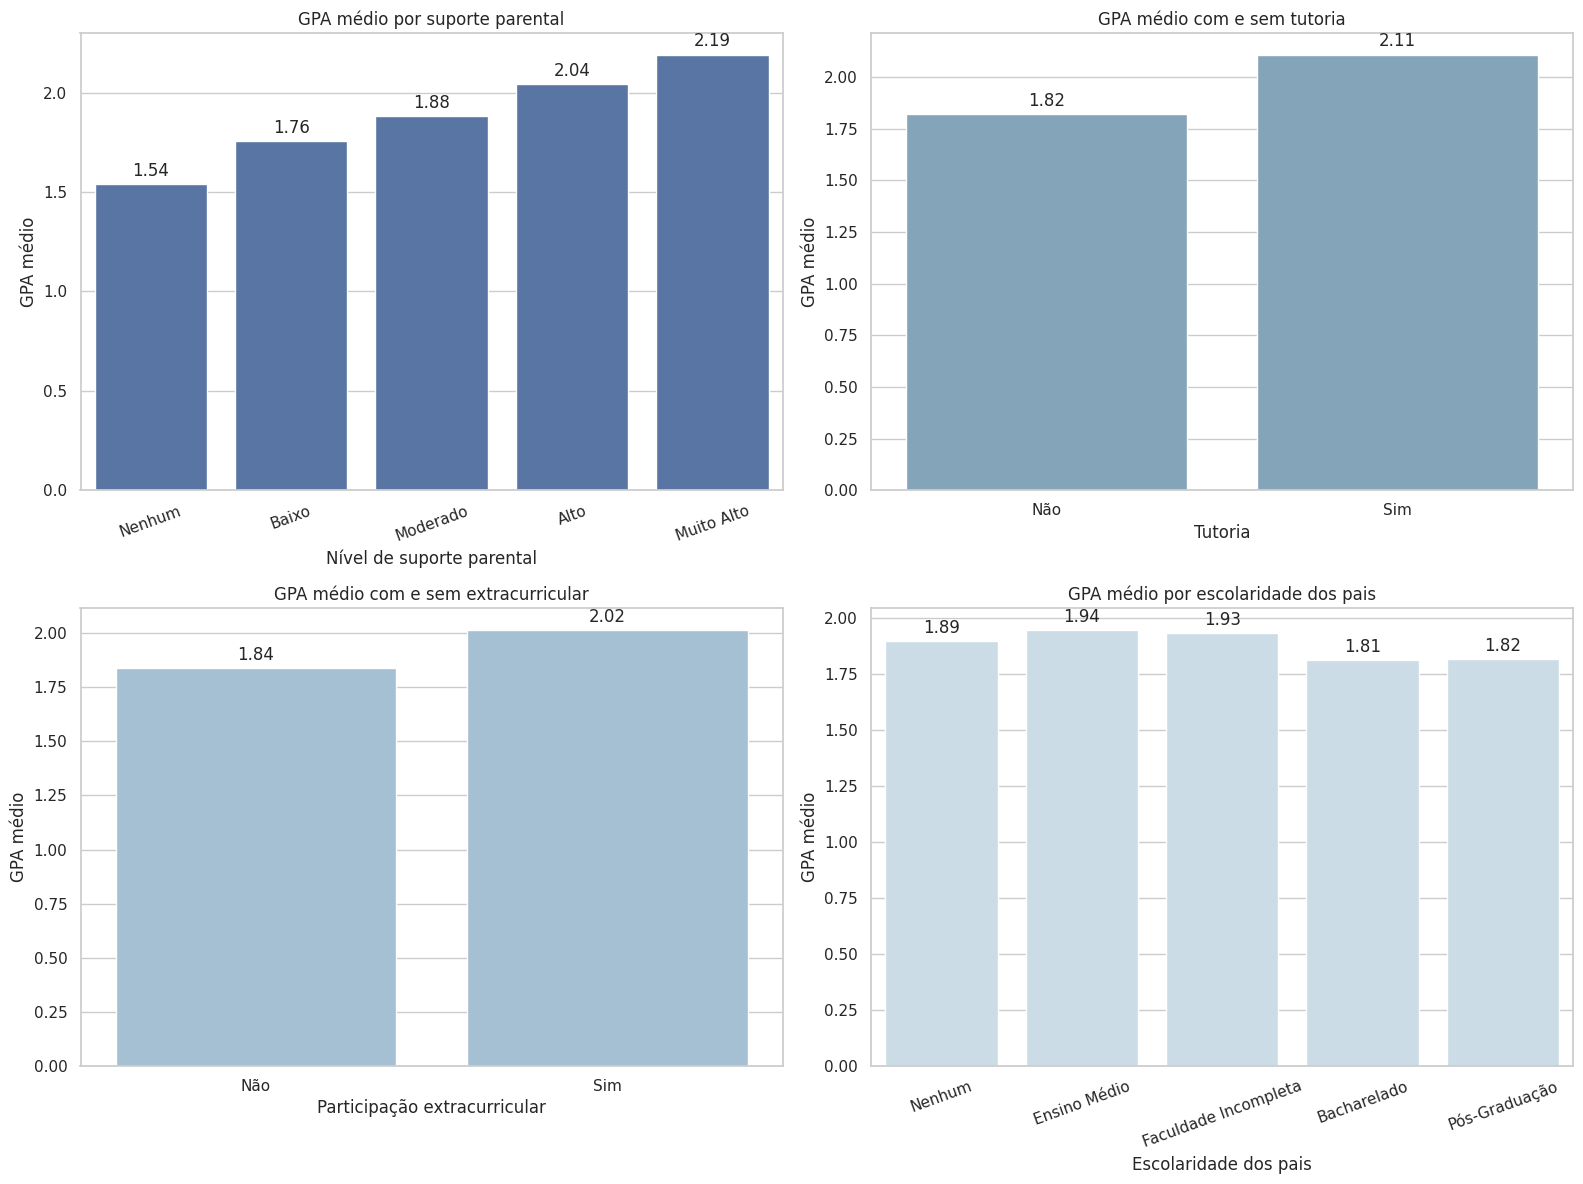

In [8]:
support_df = gold_gpa_por_suporte_parental.sort_values("ParentalSupport")
tutoring_df = gold_gpa_por_tutoria.sort_values("Tutoring")
extra_df = gold_gpa_por_extracurricular.sort_values("Extracurricular")
edu_df = gold_gpa_por_educacao_pais.sort_values("ParentalEducation")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(
    data=support_df,
    x="ParentalSupport_label",
    y="media_gpa",
    color="#4C72B0",
    ax=axes[0, 0],
)
axes[0, 0].set_title("GPA médio por suporte parental")
axes[0, 0].set_xlabel("Nível de suporte parental")
axes[0, 0].set_ylabel("GPA médio")
axes[0, 0].tick_params(axis="x", rotation=20)
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt="%.2f", padding=3)

sns.barplot(
    data=tutoring_df,
    x="Tutoring_label",
    y="media_gpa",
    color="#7AA6C2",
    ax=axes[0, 1],
)
axes[0, 1].set_title("GPA médio com e sem tutoria")
axes[0, 1].set_xlabel("Tutoria")
axes[0, 1].set_ylabel("GPA médio")
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt="%.2f", padding=3)

sns.barplot(
    data=extra_df,
    x="Extracurricular_label",
    y="media_gpa",
    color="#9EC1D9",
    ax=axes[1, 0],
)
axes[1, 0].set_title("GPA médio com e sem extracurricular")
axes[1, 0].set_xlabel("Participação extracurricular")
axes[1, 0].set_ylabel("GPA médio")
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, fmt="%.2f", padding=3)

sns.barplot(
    data=edu_df,
    x="ParentalEducation_label",
    y="media_gpa",
    color="#C7DDEA",
    ax=axes[1, 1],
)
axes[1, 1].set_title("GPA médio por escolaridade dos pais")
axes[1, 1].set_xlabel("Escolaridade dos pais")
axes[1, 1].set_ylabel("GPA médio")
axes[1, 1].tick_params(axis="x", rotation=20)
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

## 4. Combinação de Fatores e Evidências Extras

A análise fica mais útil para a gestão quando combinamos variáveis que representam comportamento acadêmico e rede de apoio.

Este bloco amplia a leitura com quatro perguntas:

- O perfil dedicado realmente se destaca?
- Quais variáveis apresentam associação mais forte com o GPA?
- A idade muda o desempenho médio de forma relevante?
- Como suporte parental e tutoria se combinam no resultado acadêmico?

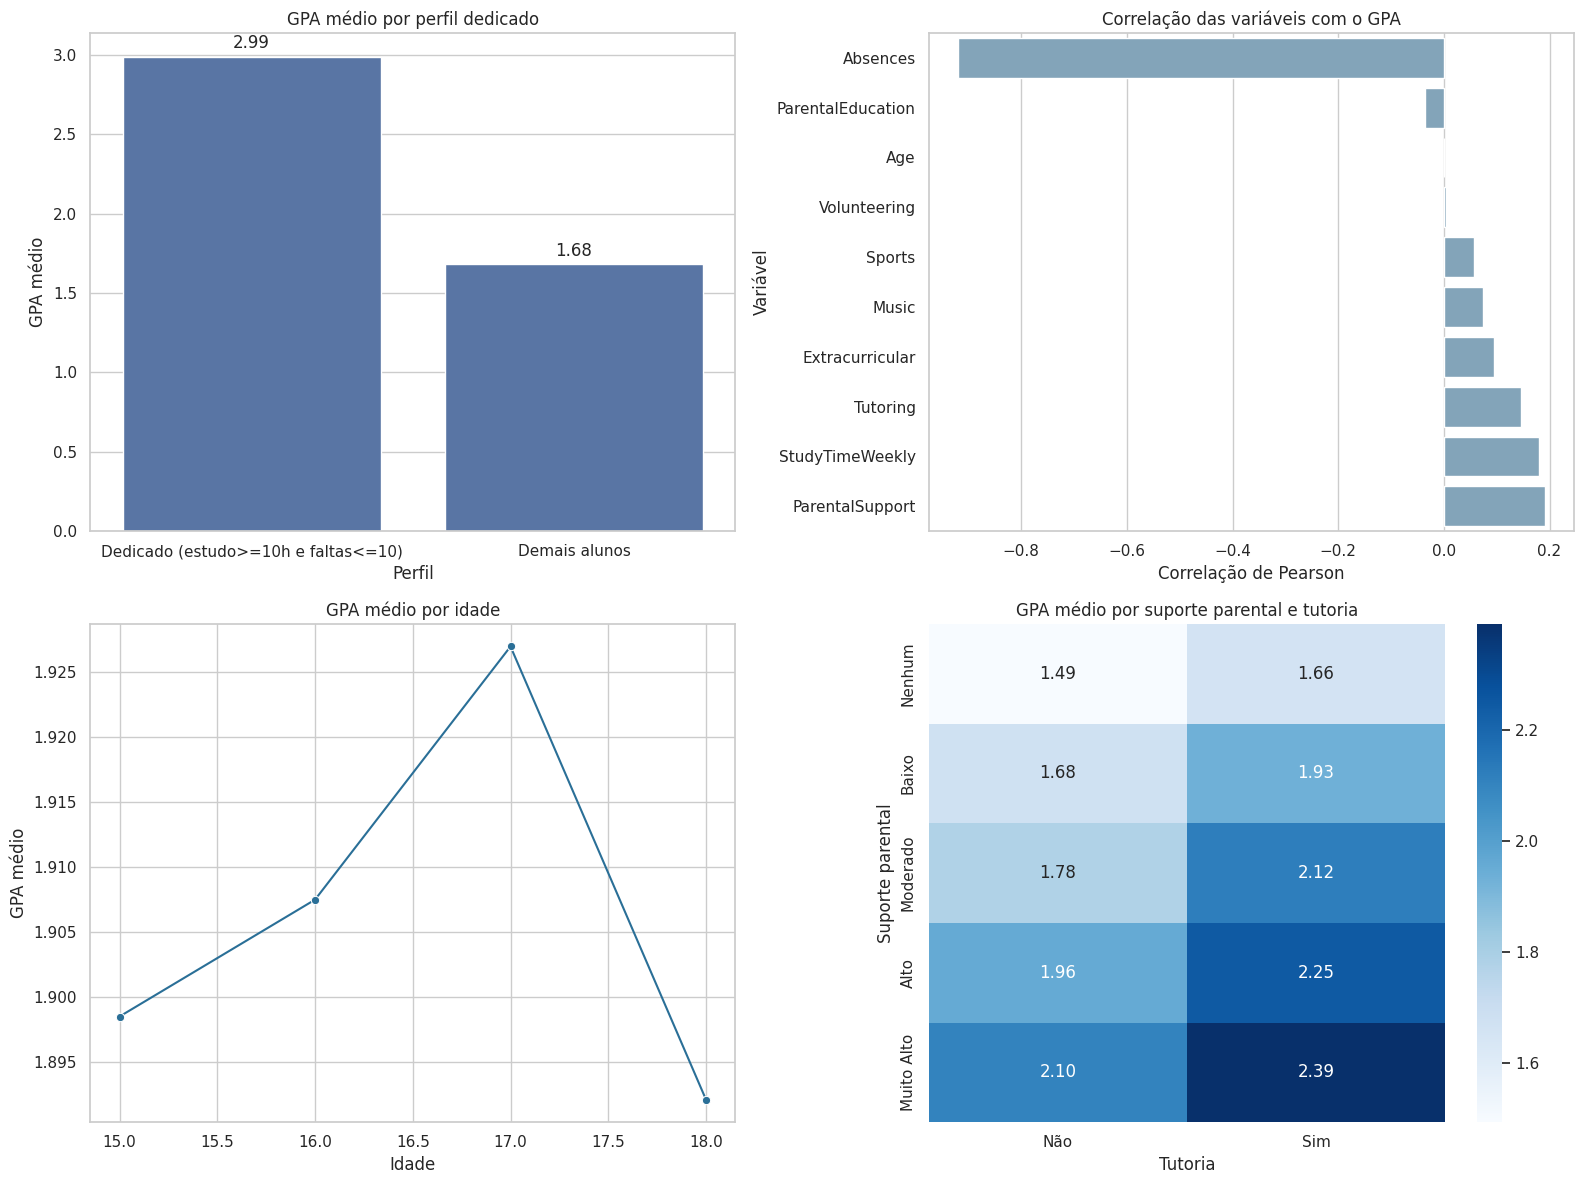

In [9]:
perfil_df = gold_gpa_perfil_dedicado.copy()
corr_df = gold_correlacao_com_gpa.sort_values("correlacao_com_gpa", ascending=True)
idade_df = gold_gpa_por_idade.sort_values("Age")

pivot_suporte_tutoria = pd.pivot_table(
    df_analise,
    values="GPA",
    index="ParentalSupport_label",
    columns="Tutoring_label",
    aggfunc="mean",
).reindex(ordem_suporte)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(
    data=perfil_df,
    x="perfil_dedicado",
    y="media_gpa",
    color="#4C72B0",
    ax=axes[0, 0],
)
axes[0, 0].set_title("GPA médio por perfil dedicado")
axes[0, 0].set_xlabel("Perfil")
axes[0, 0].set_ylabel("GPA médio")
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt="%.2f", padding=3)

sns.barplot(
    data=corr_df,
    y="variavel",
    x="correlacao_com_gpa",
    color="#7AA6C2",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Correlação das variáveis com o GPA")
axes[0, 1].set_xlabel("Correlação de Pearson")
axes[0, 1].set_ylabel("Variável")

sns.lineplot(
    data=idade_df,
    x="Age",
    y="media_gpa",
    marker="o",
    color="#2a6f97",
    ax=axes[1, 0],
)
axes[1, 0].set_title("GPA médio por idade")
axes[1, 0].set_xlabel("Idade")
axes[1, 0].set_ylabel("GPA médio")

sns.heatmap(
    pivot_suporte_tutoria,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    ax=axes[1, 1],
)
axes[1, 1].set_title("GPA médio por suporte parental e tutoria")
axes[1, 1].set_xlabel("Tutoria")
axes[1, 1].set_ylabel("Suporte parental")

plt.tight_layout()
plt.show()

## 5. Síntese Analítica e Recomendações

A leitura consolidada do notebook aponta um quadro claro: o desempenho acadêmico está concentrado nas faixas mais baixas de nota e o risco escolar é elevado.

Principais evidências observadas:

- A classe `F (GPA < 2.0)` concentra cerca de metade da base, e o grupo `Em risco / Reprovado` representa aproximadamente dois terços dos alunos.
- O GPA cresce conforme as horas de estudo aumentam e cai de forma acentuada conforme as faltas se acumulam.
- Suporte parental, tutoria e participação extracurricular aparecem como fatores associados a melhores médias.
- O perfil dedicado (`estudo >= 10h` e `faltas <= 10`) apresenta vantagem expressiva sobre os demais alunos.
- A idade, isoladamente, parece ter baixa influência quando comparada a hábitos de estudo e frequência.

Leituras práticas para a escola:

1. A gestão deve monitorar faltas como um indicador operacional de risco precoce.
2. Programas de tutoria e reforço tendem a ser mais eficazes quando direcionados a alunos com baixa frequência e baixo suporte familiar.
3. O engajamento da família deve ser tratado como parte da estratégia pedagógica, e não apenas como contexto externo.
4. Os resultados aqui são associativos e servem para priorização analítica e pedagógica, não para afirmar causalidade isolada.

In [10]:
conn.close()
print("Conexão com o SQLite encerrada. Notebook analítico concluído.")

Conexão com o SQLite encerrada. Notebook analítico concluído.
